In [8]:
BASE <- "/nfs/turbo/umms-lgarmire/home/yhdu/Bowei_NAS/EFIGA/Review/AD_RnT/MetaboAnalyst"
 
read_pathway <- function(path, group) {
  df <- read.csv(path, row.names = 1, check.names = FALSE)
  df <- df[df$Hits > 1, ]
  df <- df[df$Impact > 0.001, ]
  data.frame(
    Pathway = rownames(df),
    Impact  = df$Impact,
    logp    = df$`-log10(p)`,
    FDR     = df$FDR,
    Group   = group,
    stringsAsFactors = FALSE
  )
}


emci <- read_pathway(file.path(BASE, "Result_EFIGA_DEadj_EMCIwithin/pathway_results (4).csv"), "EMCI")
lmci <- read_pathway(file.path(BASE, "Result_EFIGA_DEadj_LMCIwithin/pathway_results (5).csv"), "LMCI")

In [9]:
library(stringr)
lmci_order <- c(
  "Alanine, aspartate and glutamate metabolism",
  "Glycine, serine and threonine metabolism",
  "Glyoxylate and dicarboxylate metabolism"
)
# Wrap names first, then set factor so order is preserved after wrapping
lmci$Pathway <- str_wrap(lmci$Pathway, width = 20)
lmci_order_wrapped <- str_wrap(lmci_order, width = 20)
lmci$Pathway <- factor(lmci$Pathway, levels = rev(lmci_order_wrapped))
 

In [23]:
library(ggplot2)
make_plot <- function(df, title_suffix) {
  if (!is.factor(df$Pathway)) {
    df$Pathway <- str_wrap(df$Pathway, width = 20)
    df$Pathway <- factor(df$Pathway, levels = rev(unique(df$Pathway)))
  }

  ggplot(df, aes(x = Impact, y = Pathway, fill = logp)) +
    geom_col(width = 0.7) +
    scale_fill_gradient(
      low  = "#C0392B",
      high = "#2980B9",
      name = "-log(p.value)",
      guide = guide_colourbar(barwidth = 0.6, barheight = 4, title.position = "top")
    ) +
    labs(
      title = paste0("EFIGA KEGG: ", title_suffix),
      x     = "Pathway Impact",
      y     = NULL
    ) +
    theme_bw(base_size = 14) +
    theme(
      plot.title       = element_text(size = 11, face = "bold", hjust = 0.5),
      panel.grid.major = element_line(colour = "grey90"),
      panel.grid.minor = element_blank(),
      legend.position  = "right"
    )
}

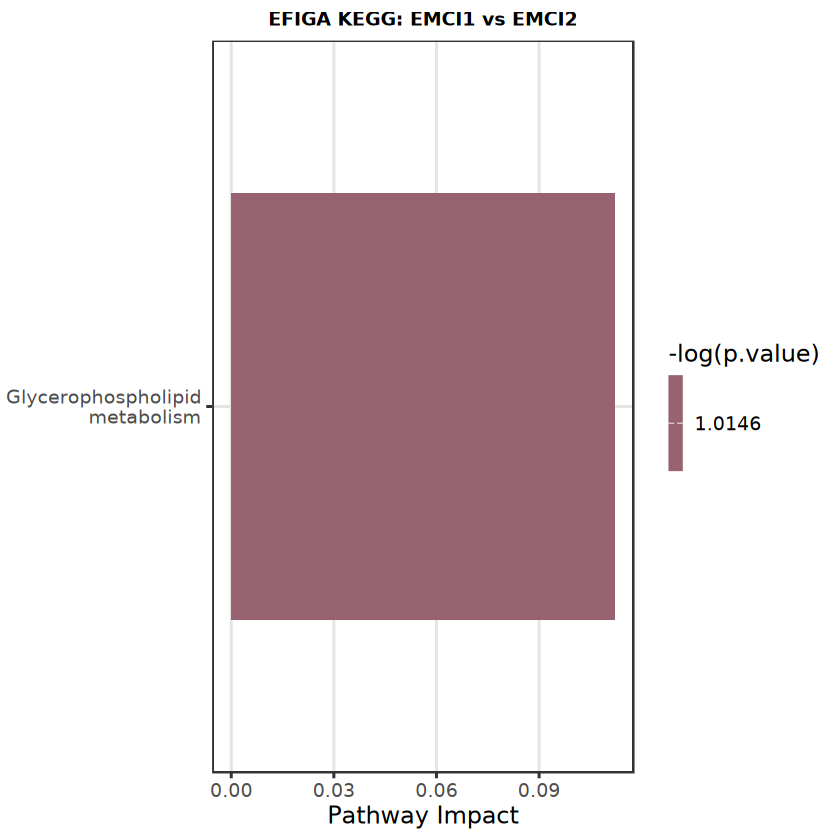

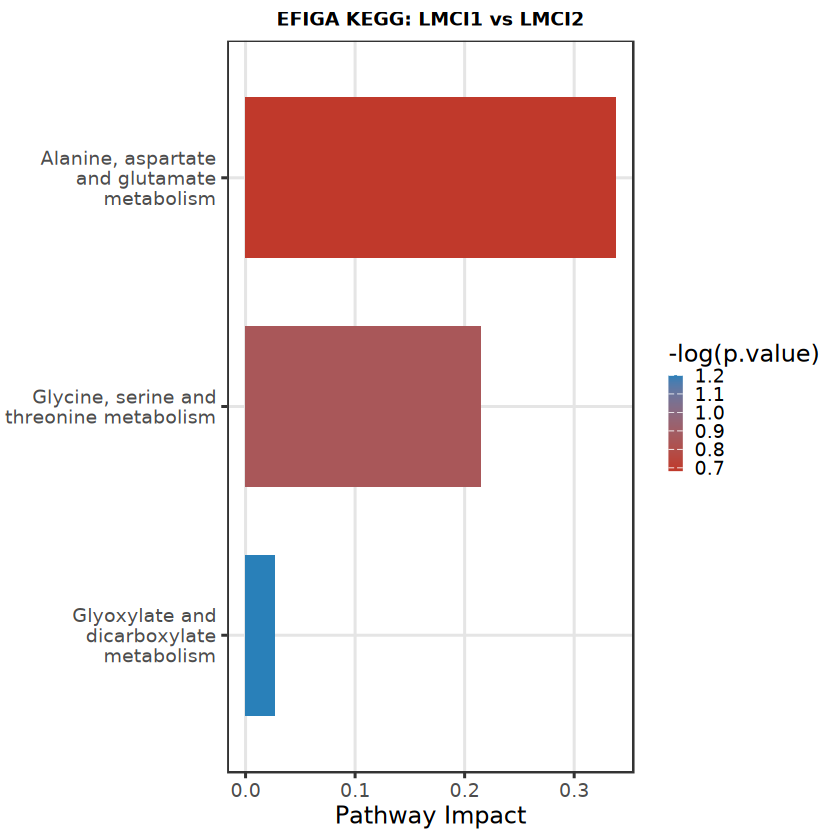

In [24]:
# ── Render ────────────────────────────────────────────────────────────────────
p_emci <- make_plot(emci, "EMCI1 vs EMCI2")
p_lmci <- make_plot(lmci, "LMCI1 vs LMCI2")
 p_emci
p_lmci

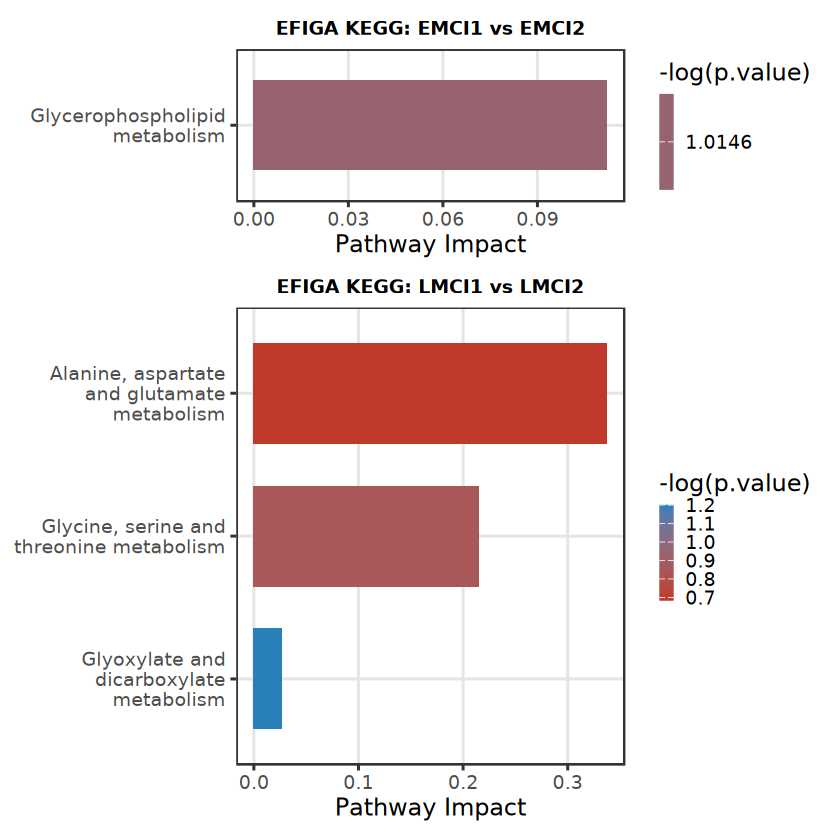

In [25]:
# Combined (stacked) — top:bottom height = 1:2
library(patchwork)
combined <- p_emci / p_lmci + plot_layout(heights = c(1, 3))
combined

In [ ]:
#ggsave("subtype_comb_lmci_emci_pathway_dotplot.png", combined, width = 12, height = 5,units = 'in',dpi=300)

In [27]:
ggsave("subtype_comb_lmci_emci_pathway_barplot.png", combined, width = 7, height = 5,units = 'in',dpi=300)